# JobBERT Chunk Classifier — Checkpoint Testing
Loads the best saved checkpoint and lets you inspect chunk-level predictions.

In [13]:
import sys
from pathlib import Path

import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

sys.path.insert(0, str(Path('.').resolve()))
from chunking import split_sentences

MODEL_DIR = 'jobbert_chunk_classifier'
# Fall back to latest epoch checkpoint if best model not saved yet
if not (Path(MODEL_DIR) / 'model.safetensors').exists():
    epoch_dirs = sorted(Path(MODEL_DIR).glob('epoch_*'), key=lambda p: int(p.name.split('_')[1]))
    MODEL_DIR = str(epoch_dirs[-1]) if epoch_dirs else MODEL_DIR

print(f'Loading from: {MODEL_DIR}')
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model.eval()
MAX_LEN = 128
print('Ready.')

Loading from: jobbert_chunk_classifier


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Ready.


In [14]:
def predict(text: str, threshold: float = 0.5) -> pd.DataFrame:
    """Return a DataFrame of chunks with P(relevant) and keep/drop decision."""
    chunks = split_sentences(text)
    if not chunks:
        return pd.DataFrame(columns=['chunk', 'p_relevant', 'keep'])

    enc = tokenizer(
        chunks,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    with torch.no_grad():
        out   = model(**enc)
        probs = torch.softmax(out.logits, dim=-1)[:, 1].numpy()

    return pd.DataFrame({
        'chunk':      chunks,
        'p_relevant': probs.round(4),
        'keep':       probs >= threshold,
    })


def summarize(text: str, threshold: float = 0.8) -> str:
    """Return relevant chunks joined as a string."""
    df = predict(text, threshold=threshold)
    return ' '.join(df.loc[df['keep'], 'chunk'])

## Compare model predictions vs Qwen ground-truth labels

In [15]:
import pyarrow.parquet as pq

row = pq.read_table('chunks_labelled_qwen_parts/batch_000050.parquet').to_pylist()[3]
print('Title:', row['title'])
print('Chunks:', len(row['chunks']))

chunk_texts = [c['chunk_text'] for c in row['chunks']]
gt_labels   = [c['label']      for c in row['chunks']]

enc = tokenizer(
    chunk_texts,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt',
)

with torch.no_grad():
    out   = model(**enc)
    probs = torch.softmax(out.logits, dim=-1)[:, 1].numpy()

df = pd.DataFrame({
    'chunk':      chunk_texts,
    'p_relevant': probs.round(4),
    'pred':       (probs >= 0.5).astype(int),
    'gt_label':   gt_labels,
})
df['correct'] = (df['pred'] == df['gt_label']) | (df['gt_label'] == -1)

pd.set_option('display.max_colwidth', 90)
df

Title: Accounts Receivable Clerk
Chunks: 24


,chunk,p_relevant,pred,gt_label,correct
0,Peridot Supply Inc is a growth oriented company engaged in wholesale distribution of b...,0.0224,0,0,True
1,Peridot is in search of a self-directed and experienced Accounts Receivable Clerk to j...,0.9951,1,1,True
2,Working alongside others in the finance group the successful candidate will be respons...,0.0278,0,0,True
3,"This is a fantastic opportunity for a professional who thrives in a busy work place, a...",0.0639,0,0,True
4,The successful candidate will be a strategic individual with 5 plus years of accountin...,0.0402,0,0,True
5,Maintain precise records of all incoming payments,0.0224,0,0,True
6,Prepare and send invoices to clients,0.0243,0,0,True
7,Contact clients as needed to ensure payment of outstanding invoices,0.0208,0,0,True
8,Reconcile any irregularities in receipts,0.0161,0,0,True
9,Work collaboratively with accounts payable and other accounting staff to ensure accura...,0.0248,0,0,True


## Custom job description

In [16]:
text = """
Machine Learning Research Lead (Quant Research)



We’re partnered with a top-tier global trading firm that is investing heavily in building out a centralized machine learning ecosystem across its trading business. This is a unique opportunity to step into a leadership role at the intersection of ML research, trading, and infrastructure shaping how machine learning is applied at scale across multiple asset classes.



The role goes beyond pure modeling. You’ll play a key role in defining the research platform, guiding experimentation, and enabling teams to deploy ML-driven strategies in production environments where performance and speed matter.



What You’ll Be Doing

Lead the design, development, and deployment of machine learning models applied to trading and market prediction
Drive research into advanced ML techniques for signal generation, forecasting, and portfolio optimization
Partner closely with traders, researchers, and engineers to translate market intuition into data-driven models and features
Oversee data pipelines, feature engineering, and integration of structured and alternative datasets
Help build and scale a centralized ML research environment used across multiple teams
Define best practices around experimentation, model validation, and productionization
Mentor and guide junior researchers while fostering a strong research-driven culture


What They’re Looking For

Advanced degree (PhD or Master’s) in a quantitative field such as computer science, mathematics, statistics, or engineering
4+ years of experience developing and deploying applied machine learning models
Experience working in performance-critical or real-time environments (trading experience is a plus, not a requirement)
Strong programming skills in Python and experience with modern ML frameworks (e.g., PyTorch, TensorFlow, JAX or similar)
Deep understanding of the theoretical foundations behind modern machine learning approaches
Experience working across research and engineering teams to bring models into production
Prior leadership or mentorship experience is a plus
Strong communication skills and ability to operate in a highly collaborative environment


Why This Role

Platform-level impact: Shape how machine learning is applied across an entire trading organization
Blend of research + leadership: Stay hands-on while influencing broader technical direction
Real-world impact: Work on problems where models directly translate to PnL
Collaborative environment: Tight integration across trading, research, and engineering
Build-mode opportunity: Help define infrastructure, not just use it
"""

df = predict(text)
pd.set_option('display.max_colwidth', 90)
df

,chunk,p_relevant,keep
0,Machine Learning Research Lead (Quant Research),0.9642,True
1,We’re partnered with a top-tier global trading firm that is investing heavily in build...,0.7577,True
2,This is a unique opportunity to step into a leadership role at the intersection of ML ...,0.7257,True
3,The role goes beyond pure modeling.,0.7496,True
4,"You’ll play a key role in defining the research platform, guiding experimentation, and...",0.9891,True
5,"Lead the design, development, and deployment of machine learning models applied to tra...",0.9671,True
6,"Advanced degree (PhD or Master’s) in a quantitative field such as computer science, ma...",0.6969,True
7,Platform-level impact: Shape how machine learning is applied across an entire trading ...,0.9449,True


In [17]:
summary = summarize(text)
print(summary if summary else '(no chunks above threshold 0.5)')

Machine Learning Research Lead (Quant Research) You’ll play a key role in defining the research platform, guiding experimentation, and enabling teams to deploy ML-driven strategies in production environments where performance and speed matter. Lead the design, development, and deployment of machine learning models applied to trading and market prediction
Drive research into advanced ML techniques for signal generation, forecasting, and portfolio optimization
Partner closely with traders, researchers, and engineers to translate market intuition into data-driven models and features
Oversee data pipelines, feature engineering, and integration of structured and alternative datasets
Help build and scale a centralized ML research environment used across multiple teams
Define best practices around experimentation, model validation, and productionization
Mentor and guide junior researchers while fostering a strong research-driven culture Platform-level impact: Shape how machine learning is app

## Threshold sweep

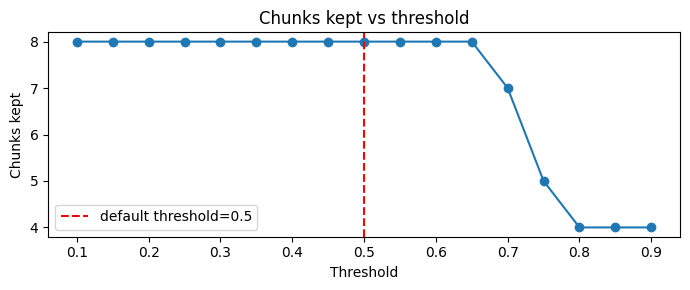

In [18]:
import numpy as np
import matplotlib.pyplot as plt

df_full    = predict(text, threshold=0.0)
thresholds = np.linspace(0.1, 0.9, 17)
counts     = [(t, (df_full['p_relevant'] >= t).sum()) for t in thresholds]

ts, ks = zip(*counts)
plt.figure(figsize=(7, 3))
plt.plot(ts, ks, marker='o')
plt.axvline(0.5, color='red', linestyle='--', label='default threshold=0.5')
plt.xlabel('Threshold'); plt.ylabel('Chunks kept')
plt.title('Chunks kept vs threshold')
plt.legend(); plt.tight_layout(); plt.show()

## Push to Hugging Face Hub
Option 1 — via training script:
```bash
python train_classifier.py --push-to-hub --hub-model-id your-username/jobbert-chunk-relevance
```

Option 2 — manually from this notebook:
```python
from huggingface_hub import login
login()   # paste your HF token

model.push_to_hub('your-username/jobbert-chunk-relevance')
tokenizer.push_to_hub('your-username/jobbert-chunk-relevance')
```

Others load it with:
```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model     = AutoModelForSequenceClassification.from_pretrained('your-username/jobbert-chunk-relevance')
tokenizer = AutoTokenizer.from_pretrained('your-username/jobbert-chunk-relevance')
```